In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
price_index = np.random.randint(3, size=100000)
trials = np.eye(3, dtype=int)[price_index]

In [26]:
initial_choice_index = np.random.randint(0, 3, size=(100000,), dtype=int)

In [27]:
def the_test_fast(initial_index, trials, switch: bool = False):
    choices = np.asarray(initial_index)
    price_index = trials.argmax(axis=1)

    same_mask = choices == price_index
    revealed_forced = 3 - choices - price_index

    other_doors = np.array([[1, 2], [0, 2], [0, 1]])
    rand_picks   = np.random.randint(0, 2, len(choices))
    revealed_random = other_doors[choices, rand_picks]

    revealed = np.where(same_mask, revealed_random, revealed_forced)

    if switch:
        choices = 3 - choices - revealed

    scores = trials[np.arange(len(choices)), choices]
    return np.cumsum(scores) / np.arange(1, len(scores) + 1)

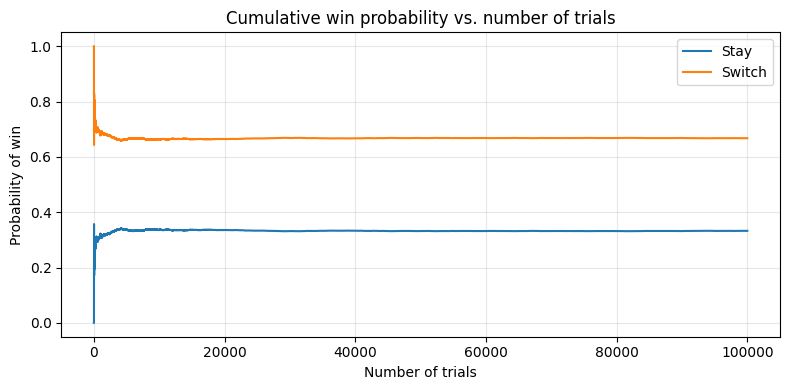

In [28]:
scores_stay = the_test(initial_choice_index, trials, switch=False)
scores_switch = the_test(initial_choice_index, trials, switch=True)

x = np.arange(1, len(scores_stay) + 1)

plt.figure(figsize=(8, 4))
plt.plot(x, scores_stay, label='Stay', linewidth=1.5)
plt.plot(x, scores_switch, label='Switch', linewidth=1.5)
plt.xlabel('Number of trials')
plt.ylabel('Probability of win')
plt.title('Cumulative win probability vs. number of trials')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()